<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/fabiobento/dnn-course-2026-1/blob/main/C1_M3_Lab_data_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

# Gerenciamento de Dados

Em laboratórios anteriores, você se concentrou em construir e treinar modelos com dados bem estruturados. No entanto, no mundo real, os dados raramente são perfeitos. Mesmo a arquitetura de modelo mais poderosa pode falhar se receber um fluxo de dados desorganizado, ineficiente ou não confiável. É aqui que um **pipeline de dados** robusto se torna essencial.

Este laboratório muda o seu foco do modelo para os dados em si, enfrentando os desafios comuns dos conjuntos de dados do mundo real. Você trabalhará com o conjunto de dados **[Oxford 102 Flowers](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/)**, uma coleção de imagens e rótulos armazenados em arquivos separados, com formatação inconsistente e possivelmente até com algumas amostras corrompidas. Para superar esses obstáculos, você usará as ferramentas de gerenciamento de dados essenciais do PyTorch: as classes **`Dataset`** e **`DataLoader`**.

Neste laboratório, você vai:

* Explorar um conjunto de dados do mundo real com arquivos desorganizados e rótulos separados.
* Construir um **`Dataset`** personalizado do PyTorch para carregar e pré-processar imagens e rótulos dinamicamente (*on the fly*).
* Aplicar **transformações** e **aumento de dados** (*data augmentation*) para preparar seus dados e melhorar a robustez do modelo.
* Usar o **`DataLoader`** para criar e embaralhar lotes (*batches*) de forma eficiente para o treinamento.
* Dividir seus dados em conjuntos de treinamento, validação e teste.
* Implementar técnicas de tratamento de erros para gerenciar problemas nos dados e monitorar o desempenho do seu pipeline.

## Importação de bibliotecas

In [1]:
# Bibliotecas padrão do Python para sistema operacional e manipulação de arquivos compactados
import os
import tarfile

# Biblioteca para plotagem de gráficos, curvas de perda/acurácia e visualização de imagens
import matplotlib.pyplot as plt

# Biblioteca fundamental para computação científica e manipulação de matrizes/vetores
import numpy as np

# Biblioteca para realizar requisições HTTP (como baixar datasets da internet)
import requests

# Biblioteca para funções matemáticas avançadas e processamento de sinais/imagens
import scipy

# Biblioteca padrão para processamento de imagens (abrir, salvar e manipular formatos)
from PIL import Image

# Componentes do PyTorch para gerenciamento de dados: criação de datasets customizados,
# criação de subconjuntos, divisão aleatória (treino/validação) e carregadores de lotes (batches)
from torch.utils.data import Dataset, Subset, random_split, DataLoader

# Módulo do PyTorch focado em transformações e aumentos de dados (Data Augmentation) em imagens
from torchvision import transforms

# Biblioteca utilizada para exibir barras de progresso interativas durante loops e treinamentos
from tqdm.auto import tqdm

# Módulo utilitário local customizado (específico para este projeto/laboratório)
import helper_utils_5

## Baixar arquivos auxiliares

In [2]:
import os

def download_files(filenames):
    """
    Baixa uma lista de arquivos do repositório do curso se eles não existirem localmente.
    """
    # URL base do repositório remoto onde os arquivos do curso estão hospedados
    base_url = "https://raw.githubusercontent.com/fabiobento/dnn-course-2026-1/main/"
    
    # Itera sobre cada nome de arquivo presente na lista fornecida
    for filename in filenames:
        # Verifica se o arquivo já existe no diretório local para evitar downloads duplicados
        if not os.path.exists(filename):
            # Monta a URL completa combinando o endereço base com o nome do arquivo
            url = f"{base_url}{filename}"
            print(f"Baixando {filename}...")
            
            # Executa uma chamada de sistema utilizando o comando 'wget'
            # A flag '-q' ativa o modo silencioso (quiet) e '-O' define o nome do arquivo de saída
            os.system(f"wget -q {url} -O {filename}")
        else:
            # Caso o arquivo já esteja presente, o script apenas notifica o usuário e pula para o próximo
            print(f"O arquivo '{filename}' já existe localmente. Pulando...")

# Lista com os arquivos auxiliares essenciais para a execução correta deste notebook:
arquivos_necessários = [
    'helper_utils_5.py',           # Script local com funções utilitárias de suporte
    'corrupted_flower_data.tar.gz', # Dataset compactado que será utilizado nas práticas
]

# Dispara a função para garantir que todos os dependências estejam disponíveis no ambiente local
download_files(arquivos_necessários)

O arquivo 'helper_utils_5.py' já existe localmente. Pulando...
O arquivo 'corrupted_flower_data.tar.gz' já existe localmente. Pulando...


In [3]:
# Descompacta o arquivo do dataset 'corrupted_flower_data.tar.gz' 
# -x: extrai os arquivos
# -z: descompacta o formato gzip
# -f: especifica o nome do arquivo a ser tratado
!tar -xzf corrupted_flower_data.tar.gz

## Acesso aos Dados

Todo projeto de *deep learning* começa com dados, mas nem todos os dados estão prontos para uso. Às vezes eles já estão bem organizados, mas frequentemente estão dispersos ou armazenados em formatos que não são diretamente compatíveis com o treinamento de modelos.

Nesta seção, você aprenderá a gerenciar o acesso aos dados e a seguir as melhores práticas para trabalhar com conjuntos de dados desorganizados ou inconsistentes.

### Exploração do Conjunto de Dados

O primeiro passo ao trabalhar com um novo conjunto de dados é acessar e explorar sua estrutura. Isso ajuda você a entender como os dados estão organizados e, portanto, como carregá-los e utilizá-los de maneira eficaz.

* Você definirá uma função `download_dataset` que baixa o conjunto de dados de uma determinada URL e o extrai para um diretório especificado.
* Neste caso, o conjunto de dados consiste em dois arquivos: um arquivo `.tgz` com as imagens e um arquivo `.mat` contendo os rótulos.

Ambos os arquivos serão baixados usando a biblioteca `requests` e, em seguida, extraídos usando a biblioteca `tarfile`.

In [4]:
def download_dataset():
    """
    Baixa e extrai um dataset a partir de URLs remotas se ele já não estiver presente localmente.

    Esta função primeiro verifica a existência dos arquivos do dataset em um diretório
    específico. Se os arquivos não forem encontrados, ela faz o download a partir de
    URLs predefinidas e, em seguida, extrai o conteúdo.
    """
    # Define o diretório onde o dataset será armazenado.
    data_dir = "flower_data"
    
    # Define os caminhos para pastas e arquivos essenciais.
    image_folder_path = os.path.join(data_dir, "jpg")
    labels_file_path = os.path.join(data_dir, "imagelabels.mat")
    tgz_path = os.path.join(data_dir, "102flowers.tgz")

    # Verifica se a pasta principal de dados e o arquivo de rótulos (labels) já existem.
    if os.path.exists(image_folder_path) and os.path.exists(labels_file_path):
        # Informa ao usuário que o dataset já está disponível localmente e cancela o download.
        print(f"O dataset já existe. Carregando localmente a partir de '{data_dir}'.")
        # Encerra a função, já que nenhum download é necessário.
        return

    # Informa ao usuário que o dataset não foi encontrado e que o download vai começar.
    print("Dataset não encontrado localmente. Iniciando download...")

    # Define as URLs para o arquivo compactado das imagens e para o arquivo de rótulos.
    image_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz"
    labels_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat"

    # Cria o diretório de destino para o dataset, caso ele ainda não exista.
    os.makedirs(data_dir, exist_ok=True)

    # Anuncia o início do processo de download das imagens.
    print("Baixando imagens...")
    # Envia uma requisição HTTP GET para a URL da imagem, habilitando streaming para arquivos grandes.
    response = requests.get(image_url, stream=True)
    # Obtém o tamanho total do arquivo a partir dos cabeçalhos de resposta para a barra de progresso.
    total_size = int(response.headers.get("content-length", 0))

    # Abre um arquivo local no modo de escrita binária para salvar o pacote baixado.
    with open(tgz_path, "wb") as file:
        # Itera sobre o conteúdo da resposta em pedaços (chunks) junto com uma barra de progresso.
        for data in tqdm(
            # Define o tamanho do pedaço para iterar sobre o conteúdo.
            response.iter_content(chunk_size=1024),
            # Define o total para a barra de progresso com base no tamanho do arquivo em kilobytes.
            total=total_size // 1024,
        ):
            # Escreve cada pedaço de dados no arquivo local.
            file.write(data)

    # Anuncia o início do processo de extração do arquivo.
    print("Extraindo arquivos...")
    # Abre o arquivo tar.gz baixado no modo de leitura.
    with tarfile.open(tgz_path, "r:gz") as tar:
        # Extrai todo o conteúdo do arquivo compactado dentro do diretório de destino.
        tar.extractall(data_dir)

    # Anuncia o início do download do arquivo de rótulos (labels).
    print("Baixando rótulos (labels)...")
    # Envia uma requisição HTTP GET para a URL dos rótulos.
    response = requests.get(labels_url)
    # Abre um arquivo local no modo de escrita binária para salvar os rótulos.
    with open(labels_file_path, "wb") as file:
        # Escreve todo o conteúdo recebido na resposta diretamente no arquivo.
        file.write(response.content)

    # Informa ao usuário que o download e a extração foram concluídos com sucesso.
    print(f"Dataset baixado e extraído com sucesso para '{data_dir}'.")

    # Lista contendo a descrição textual de cada uma das 102 classes de flores
    labels_description = [
        'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily',
        'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea',
        'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
        'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth',
        'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation',
        'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower',
        'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia',
        'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia',
        'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia',
        'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy',
        'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily',
        'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani',
        'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen ', 'watercress',
        'canna lily', 'hippeastrum ', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow',
        'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily'
    ]

    # Salva os nomes textuais das classes em ordem em um arquivo de texto estruturado
    with open(os.path.join(data_dir, "labels_description.txt"), "w") as f:
        for idx, label in enumerate(labels_description, start=1):
            f.write(f"{label}\n")

In [5]:
# Chama a função para baixar, extrair e preparar o dataset de flores.
download_dataset()

O dataset já existe. Carregando localmente a partir de 'flower_data'.


In [6]:
# Define o caminho para o diretório raiz do dataset.
path_dataset = './flower_data'

# Exibe a estrutura de pastas do diretório do dataset até uma profundidade máxima de um nível.
helper_utils_5.print_data_folder_structure(path_dataset, max_depth=1)

flower_data/
├── 102flowers.tgz
├── imagelabels.mat
├── jpg/
└── labels_description.txt


Você pode ver que o conjunto de dados consiste em:

* Uma pasta `jpg` contendo imagens no formato JPEG
* Um arquivo `imagelabels.mat` que armazena os rótulos (formato MATLAB)
* Um arquivo `labels_description.txt` que descreve cada rótulo

Isso lhe dá uma noção clara de como o conjunto de dados está estruturado e com o que você estará trabalhando.

### Criando uma Classe Dataset Personalizada

Após baixar e explorar brevemente o conjunto de dados, o próximo passo é criar uma classe *dataset* personalizada que organize o acesso aos dados. O objetivo é recuperar as imagens e seus respectivos rótulos de forma consistente e eficiente para o treinamento do modelo.

Você criará uma classe `FlowerDataset` que herda de `torch.utils.data.Dataset`.
Uma classe *dataset* personalizada *deve* implementar os seguintes métodos:

> `__init__`: Inicializa o objeto do conjunto de dados.
> * Normalmente aceita o caminho dos dados e quaisquer transformações (*transforms*) a serem aplicadas.
> * Opcionalmente, carrega metadados ou rótulos associados aos dados.
> 
> 
> `__len__`: Retorna o número de amostras no conjunto de dados.
> `__getitem__`: Recupera uma única amostra com base em um índice.
> * Carrega a imagem e seu rótulo, aplica as transformações e os retorna.
> 
> 

Além disso, você definirá métodos auxiliares (*helper methods*) para deixar o código mais limpo e organizado:

> `load_and_correct_labels`: Carrega os rótulos das imagens a partir do arquivo .mat do MATLAB.
> * Utiliza `scipy.io.loadmat` para ler o arquivo e extrair a matriz (*array*) de rótulos.
> * Os rótulos são ajustados subtraindo 1, o que é necessário porque o MATLAB usa indexação baseada em 1, enquanto o Python usa indexação baseada em 0.
> * Essa correção evita erros de deslocamento por um (*off-by-one errors*) durante o treinamento e a avaliação.
> 
> 
> 
> 
> `retrieve_image`: Carrega uma imagem do disco a partir do seu índice `idx`.
> * Com base no `idx`, reconstrói o nome do arquivo e o caminho, abre a imagem usando a biblioteca Pillow, converte-a para o formato RGB (para garantir a consistência) e retorna o objeto da imagem.
> 
> 
> `get_label_description`: Dado um rótulo, retorna uma descrição legível por humanos a partir do arquivo de texto.

**Sobre o carregamento tardio (*lazy loading*)**:
As imagens não são carregadas todas de uma vez quando o objeto do *dataset* é criado.
Em vez disso, elas são carregadas dinamicamente (*on the fly*) quando acessadas através do método `__getitem__`.
Essa abordagem é eficiente em termos de memória, especialmente ao lidar com grandes conjuntos de dados, pois evita carregar todas as imagens na memória simultaneamente.

In [7]:
class FlowerDataset(Dataset):
    """
    Uma classe de dataset customizada para carregar dados de imagens.

    Esta classe foi projetada para funcionar com as abstrações Dataset e DataLoader
    do PyTorch. Ela gerencia o carregamento de imagens e seus respectivos rótulos
    (labels) a partir de uma estrutura de diretórios específica.
    """
    def __init__(self, root_dir, transform=None):
        """
        Inicializa o objeto do dataset.

        Args:
            root_dir (str): O diretório raiz onde o dataset está armazenado.
            transform (callable, opcional): Transformação opcional a ser aplicada
                em uma amostra.
        """
        # Armazena o caminho do diretório raiz.
        self.root_dir = root_dir
        # Armazena as transformações opcionais.
        self.transform = transform
        # Cria o caminho completo para o diretório de imagens.
        self.image_dir = os.path.join(self.root_dir, "jpg")
        # Carrega e processa os rótulos a partir do arquivo correspondente.
        self.labels = self.load_and_correct_labels()

    def __len__(self):
        """
        Retorna o número total de amostras no dataset.

        Returns:
            total_samples (int): O número total de itens no dataset.
        """
        # O número total de amostras é a quantidade de rótulos existentes.
        total_samples = len(self.labels)
        # Retorna o número total de amostras.
        return total_samples

    def __getitem__(self, idx):
        """
        Recupera uma amostra do dataset no índice especificado.

        Args:
            idx (int): O índice da amostra a ser recuperada.

        Returns:
            image (PIL.Image.Image ou torch.Tensor): Os dados da imagem processada.
            label (int): O rótulo correspondente para a imagem.
        """
        # Recupera a imagem para o índice fornecido.
        image = self.retrieve_image(idx)

        # Verifica se uma transformação foi fornecida.
        if self.transform is not None:
            # Aplica a transformação à imagem.
            image = self.transform(image)

        # Obtém o rótulo correspondente ao índice.
        label = self.labels[idx]

        # Retorna a imagem processada e seu respectivo rótulo.
        return image, label

    def retrieve_image(self, idx):
        """
        Carrega uma única imagem do disco com base no seu índice.

        Args:
            idx (int): O índice da imagem a ser carregada.

        Returns:
            image (PIL.Image.Image): A imagem carregada, convertida para RGB.
        """
        # Cria o nome do arquivo da imagem com base no índice (ex: image_00001.jpg).
        img_name = f"image_{idx + 1:05d}.jpg"
        # Cria o caminho completo para o arquivo de imagem.
        img_path = os.path.join(self.image_dir, img_name)
        # Abre o arquivo de imagem.
        with Image.open(img_path) as img:
            # Converte a imagem para o espaço de cores RGB.
            image = img.convert("RGB")
        # Retorna a imagem convertida.
        return image

    def load_and_correct_labels(self):
        """
        Carrega os rótulos de um arquivo e os ajusta para indexação baseada em zero.

        Returns:
            labels (numpy.ndarray): Um array de rótulos inteiros indexados em zero.
        """
        # Carrega o arquivo MATLAB contendo os rótulos.
        self.labels_mat = scipy.io.loadmat(
            os.path.join(self.root_dir, "imagelabels.mat")
        )
        # Extrai o array de rótulos e corrige para indexação baseada em zero (padrão Python).
        labels = self.labels_mat["labels"][0] - 1
        # Retorna os rótulos processados.
        return labels

    def get_label_description(self, label):
        """
        Recupera a descrição em texto para um determinado índice de rótulo.

        Args:
            label (int): O rótulo do tipo inteiro.

        Returns:
            description (str): A descrição textual correspondente do rótulo.
        """
        # Cria o caminho para o arquivo que contém as descrições dos rótulos.
        path_labels_description = os.path.join(self.root_dir, "labels_description.txt")
        # Abre o arquivo de descrição de rótulos para leitura.
        with open(path_labels_description, "r") as f:
            # Lê todas as linhas do arquivo.
            lines = f.readlines()
        # Obtém a descrição para o rótulo especificado e remove espaços extras no início/fim.
        description = lines[label].strip()
        # Retorna a descrição limpa.
        return description

In [8]:
# Inicializa o objeto do dataset, fornecendo o caminho para os dados.
dataset = FlowerDataset(path_dataset)

É uma boa prática verificar se a sua classe *dataset* funciona como esperado antes de utilizá-la para treinar um modelo.

Após criar uma instância da classe `FlowerDataset`, você irá:

* Verificar o número total de amostras no conjunto de dados usando a função `len()`.

In [9]:
# Imprime o número total de amostras presentes no dataset.
print(f'Número de amostras no dataset: {len(dataset)}')

Número de amostras no dataset: 8189


* Recuperar uma amostra específica usando um índice.

In [10]:
# Define o índice da amostra que deseja recuperar.
sel_idx = 10

# Recupera a imagem e o rótulo (label) correspondentes ao índice selecionado.
img, label = dataset[sel_idx]

- Inspecione o tamanho e rótulo da imagem.

In [11]:
# Cria uma string detalhando as dimensões (largura e altura) da imagem.
img_size_info = f"Tamanho da imagem: {img.size}"

# Imprime as informações de tamanho da imagem junto com o seu respectivo rótulo.
print(f'{img_size_info}, Rótulo: {label}')

Tamanho da imagem: (500, 748), Rótulo: 76


<br>

* Visualize a imagem utilizando a função auxiliar `plot_img`.

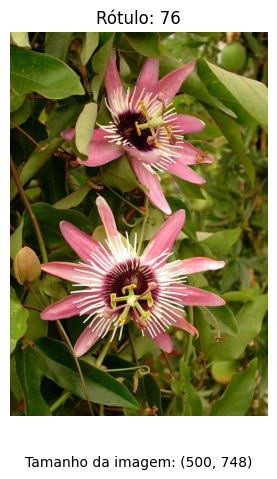

In [12]:
# Plota a imagem na tela, exibindo o rótulo como título e as dimensões como informação adicional.
helper_utils_5.plot_img(img, label=label, info=img_size_info)

Em seguida, inspecione os rótulos no conjunto de dados. Para cada rótulo único, imprima sua descrição correspondente usando o método `get_label_description`.

Como estão os rótulos?

In [13]:
# Obtém todos os rótulos (labels) do objeto do dataset.
dataset_labels = dataset.labels

# Cria um conjunto (set) de rótulos únicos para remover as duplicatas.
unique_labels = set(dataset_labels)

# Itera através de cada rótulo único.
for label in unique_labels:
    # Imprime o rótulo numérico e a sua descrição textual correspondente.
    print(f'Rótulo: {label}, Descrição: {dataset.get_label_description(label)}')

Rótulo: 0, Descrição: pink primrose
Rótulo: 1, Descrição: hard-leaved pocket orchid
Rótulo: 2, Descrição: canterbury bells
Rótulo: 3, Descrição: sweet pea
Rótulo: 4, Descrição: english marigold
Rótulo: 5, Descrição: tiger lily
Rótulo: 6, Descrição: moon orchid
Rótulo: 7, Descrição: bird of paradise
Rótulo: 8, Descrição: monkshood
Rótulo: 9, Descrição: globe thistle
Rótulo: 10, Descrição: snapdragon
Rótulo: 11, Descrição: colt's foot
Rótulo: 12, Descrição: king protea
Rótulo: 13, Descrição: spear thistle
Rótulo: 14, Descrição: yellow iris
Rótulo: 15, Descrição: globe-flower
Rótulo: 16, Descrição: purple coneflower
Rótulo: 17, Descrição: peruvian lily
Rótulo: 18, Descrição: balloon flower
Rótulo: 19, Descrição: giant white arum lily
Rótulo: 20, Descrição: fire lily
Rótulo: 21, Descrição: pincushion flower
Rótulo: 22, Descrição: fritillary
Rótulo: 23, Descrição: red ginger
Rótulo: 24, Descrição: grape hyacinth
Rótulo: 25, Descrição: corn poppy
Rótulo: 26, Descrição: prince of wales feathe

### Visão Geral das Imagens no Conjunto de Dados

Agora que você tem uma classe *dataset* funcional, você pode explorar as imagens no conjunto de dados. Você utilizará a função `visual_exploration` para visualizar algumas imagens e obter uma melhor compreensão dos dados.

In [14]:
def visual_exploration(dataset, num_rows=2, num_cols=4):
    """
    Exibe uma grade de amostras selecionadas aleatoriamente de um dataset para inspeção visual.

    Args:
        dataset (Dataset): O objeto do dataset de onde as amostras serão extraídas. Deve suportar
            indexação e possuir o método `get_label_description`.
        num_rows (int): O número de linhas na grade de exibição.
        num_cols (int): O número de colunas na grade de exibição.
    """
    # Calcula o número total de imagens a serem exibidas na grade.
    total_samples = num_rows * num_cols

    # Seleciona um conjunto aleatório de índices únicos a partir do dataset.
    indices = np.random.choice(len(dataset), total_samples, replace=False)

    # Cria uma grade de subplots para acomodar as imagens.
    fig, axes = helper_utils_5.get_grid(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 4))

    # Itera sobre cada eixo do subplot e o índice da amostra aleatória correspondente.
    for ax, idx in zip(axes.flatten(), indices):
        # Recupera a imagem e seu rótulo numérico a partir do dataset.
        image, label = dataset[idx]

        # Obtém a descrição textual legível por humanos para o rótulo.
        description = dataset.get_label_description(label)

        # Formata uma nova string de rótulo que inclui tanto o número quanto a descrição.
        label = f"{label} - {description}"

        # Cria uma string de informação com o índice da amostra e as dimensões da imagem.
        info = f"Índice: {idx} Tam: {image.size}"
        
        # Plota a imagem no subplot atual com seu respectivo rótulo e informações.
        helper_utils_5.plot_img(image, label=label, info=info, ax=ax)

    # Renderiza e exibe toda a grade de imagens na tela.
    plt.show()

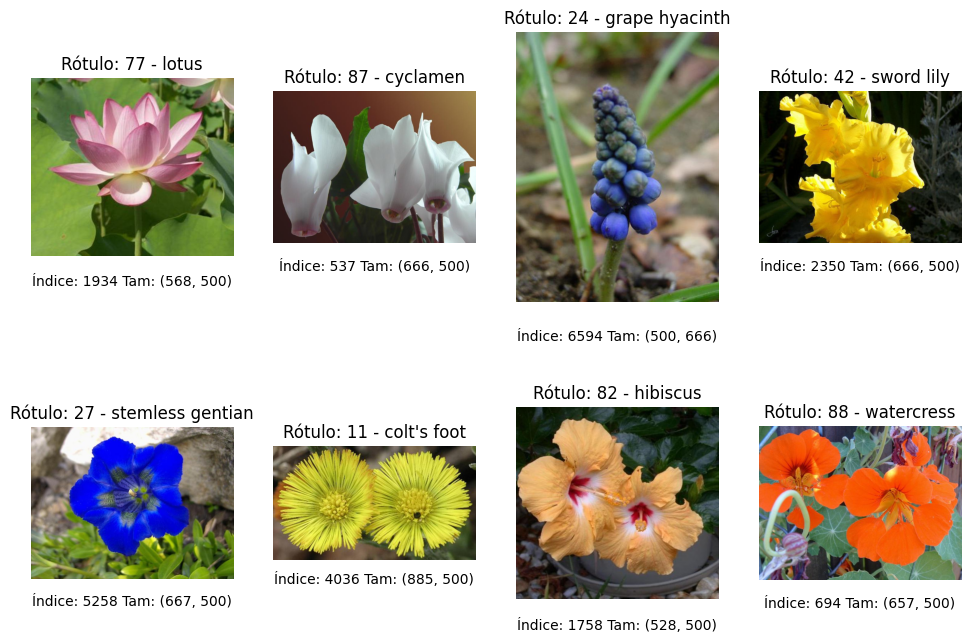

In [ ]:
# Exibe uma grade 2x4 de amostras aleatórias do dataset para inspeção visual.
visual_exploration(dataset, num_rows=2, num_cols=4)

## Problemas de Qualidade

Como você viu na seção anterior, o tamanho das imagens no conjunto de dados varia significativamente. Isso pode ser um problema ao treinar um modelo, pois a maioria dos modelos espera que as imagens de entrada tenham o mesmo tamanho. Para resolver esse problema, você implementará uma série de transformações para padronizar o tamanho das imagens.

### Transformações

Após explorar o conjunto de dados e identificar potenciais problemas de qualidade, o próximo passo é aplicar transformações para pré-processar as imagens.
As transformações são operações que modificam as imagens para prepará-las para o treinamento do modelo. Exemplos comuns incluem redimensionamento (*resizing*), recorte (*cropping*), espelhamento (*flipping*) e normalização dos valores dos pixels.
O módulo `torchvision.transforms` fornece uma variedade de transformações pré-definidas que podem ser facilmente aplicadas às imagens.

Você começará definindo um pipeline de transformação simples composto por duas etapas:

Transformações **aplicadas diretamente às imagens brutas**:

* `Resize((256, 256))`: Redimensiona cada imagem para um tamanho fixo de 256x256 pixels.
* `CenterCrop(224)`: Recorta o centro da imagem para 224x224 pixels.

Transformações que **convertem e padronizam as imagens**:

* `ToTensor()`: Converte uma imagem PIL ou matriz NumPy em um tensor e dimensiona os valores dos pixels para o intervalo [0, 1].
* `Normalize(mean, std)`: Normaliza o tensor usando a média (*mean*) e o desvio padrão (*std*) especificados.

**Nota**:
A ordem das transformações frequentemente importa. O redimensionamento e o recorte devem ser aplicados antes de converter a imagem em um tensor.

In [16]:
# Define the mean values for normalization.
mean = [0.485, 0.456, 0.406]
# Define the standard deviation values for normalization.
std = [0.229, 0.224, 0.225]

In [17]:
transform = transforms.Compose([
    # images transforms
    transforms.Resize((256, 256)),  # Resize images to 256x256 pixels
    transforms.CenterCrop(224),  # Center crop to 224x224 pixels
    # bridge to tensor
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    # tensor transforms
    transforms.Normalize(mean=mean, std=std),
])

You will now create a new instance of the `FlowerDataset` class, this time passing the transformation pipeline `transform` as an argument.

In [18]:
# Create a new dataset instance with the specified image transformations.
dataset_transformed = FlowerDataset(path_dataset, transform=transform)

Inspect the same sample again to see the effect of the transformations. Using `quick_debug`, you can see that the image has been resized and cropped to 224x224 pixels, and its pixel values have been normalized.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


Formato: torch.Size([3, 224, 224])
Tipo: torch.float32
Intervalo de valores de pixel: [-2.1, 2.6]


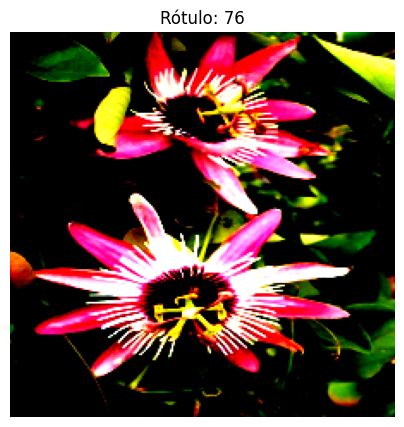

In [19]:
# Retrieve the transformed image and its label using the same index.
img_transformed, label = dataset_transformed[sel_idx]

# quick check
helper_utils_5.quick_debug(img_transformed)

# Plot the transformed image
helper_utils_5.plot_img(img_transformed, label=label)

<br>

Observe that the image is now a tensor with shape `[3, 224, 224]` representing 3 color channels (RGB) and 224x224 pixels.
Because the pixel values have been normalized, they are no longer in the original range of [0, 255].

That is why the image looks different when visualized directly.
To display it correctly, you need to *denormalize* it first. You can do this by applying the `Normalize` transformation again, using `new_mean` and `new_std` values to reverse the normalization process.

In [20]:
class Denormalize:
    """
    A callable class to reverse the normalization of a tensor image.

    This class calculates the inverse transformation of a standard normalization
    and can be used as a transform step, for instance, to visualize images
    after they have been normalized for a model.
    """
    def __init__(self, mean, std):
        """
        Initializes the denormalization transform.

        Args:
            mean (list or tuple): The mean values used for the original normalization.
            std (list or tuple): The standard deviation values used for the original normalization.
        """
        # Calculate the adjusted mean for the denormalization process.
        new_mean = [-m / s for m, s in zip(mean, std)]
        # Calculate the adjusted standard deviation for the denormalization process.
        new_std = [1 / s for s in std]
        # Create a Normalize transform object with the inverse parameters.
        self.denormalize = transforms.Normalize(mean=new_mean, std=new_std)

    def __call__(self, tensor):
        """
        Applies the denormalization transform to a tensor.

        Args:
            tensor (torch.Tensor): The normalized tensor to be denormalized.

        Returns:
            denormalized_tensor (torch.Tensor): The denormalized tensor.
        """
        # Apply the denormalization transform to the input tensor.
        denormalized_tensor = self.denormalize(tensor)
        
        # Return the denormalized tensor.
        return denormalized_tensor

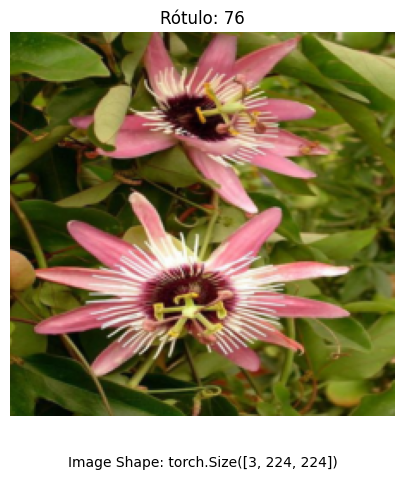

In [21]:
# Create an instance of the Denormalize class with the original mean and std.
denormalize = Denormalize(mean=mean, std=std)
# Apply the denormalization transform to the image tensor.
img_tensor = denormalize(img_transformed)

# Create an information string with the tensor's shape.
img_shape_info = f"Image Shape: {img_tensor.size()}"
# Plot the denormalized image to visualize the result.
helper_utils_5.plot_img(img_tensor, label=label, info=img_shape_info)

## Data Loading

In this section, you will learn how to prepare and serve data efficiently for model training in PyTorch.
A full training process typically includes three stages: training, validation, and evaluation.

During training, the model learns from the training data by adjusting its weights based on the loss function. 
During validation, the model is evaluated on a separate dataset to tune hyperparameters and prevent overfitting.
During evaluation, the model's performance is tested on unseen data to assess its generalization ability.

Each of these stages requires splitting the dataset into distinct subsets and using data loaders to feed data efficiently during training and testing. In what follows, you will see how to do this using PyTorch.

### Splitting the Dataset

The `split_dataset` function will divide the dataset into training, validation, and test sets.
To do this, you will:

* Define the sizes of each subset from the given fractions for validation and test.
* Make use of `random_split` from `torch.utils.data` to perform the actual split.

In [22]:
def split_dataset(dataset, val_fraction=0.15, test_fraction=0.15):
    """
    Splits a dataset into training, validation, and test sets.
    
    By default, this function partitions the data into 70% for training,
    15% for validation, and 15% for testing.

    Args:
        dataset (torch.utils.data.Dataset): The complete dataset to be split.
        val_fraction (float): The proportion of the dataset to reserve for validation.
        test_fraction (float): The proportion of the dataset to reserve for testing.

    Returns:
        train_dataset (torch.utils.data.Subset): The dataset split allocated for training.
        val_dataset (torch.utils.data.Subset): The dataset split allocated for validation.
        test_dataset (torch.utils.data.Subset): The dataset split allocated for testing.
    """

    # Calculate the total number of items in the dataset.
    total_size = len(dataset)
    
    # Calculate the number of items for the validation set.
    val_size = int(total_size * val_fraction)
    
    # Calculate the number of items for the test set.
    test_size = int(total_size * test_fraction)
    
    # Calculate the remaining number of items for the training set.
    train_size = total_size - val_size - test_size

    # Partition the dataset into the calculated sizes.
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size]
    )
    
    # Return the resulting dataset partitions.
    return train_dataset, val_dataset, test_dataset

#### Applying Transforms to Subsets

When using `random_split`, each resulting split is a `Subset` object that references the original dataset. If the original dataset already has a transform, those subsets inherit it and you cannot assign a different transform directly.

To handle this correctly, you will:

1. Split the **raw** (untransformed) dataset so that each subset returns plain PIL images.
2. Wrap each subset with `SubsetWithTransform`, a lightweight wrapper that applies a given transform when a sample is retrieved.

This pattern gives you full control over which transform each subset uses and avoids the problem of transforms being applied twice.

In [23]:
class SubsetWithTransform(Dataset):
    """
    A wrapper for a PyTorch Subset that applies a specific transformation.

    This class allows for applying a different set of transformations to a
    subset of a dataset, which is useful for creating distinct training,
    validation, or test sets with different preprocessing steps from the
    same base dataset.
    """
    def __init__(self, subset, transform=None):
        """
        Initializes the SubsetWithTransform object.

        Args:
            subset (torch.utils.data.Subset): A PyTorch Subset object containing a portion of a dataset.
            transform (callable, optional): An optional transform to be applied
                to the samples within this subset.
        """
        # Store the original subset of the dataset.
        self.subset = subset
        # Store the transformations to be applied.
        self.transform = transform

    def __len__(self):
        """
        Returns the total number of samples in the subset.

        Returns:
            subset_length (int): The total number of items in the subset.
        """
        # Calculate the length of the underlying subset.
        subset_length = len(self.subset)
        # Return the calculated length.
        return subset_length

    def __getitem__(self, idx):
        """
        Retrieves a sample and applies the transform.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            image (torch.Tensor or PIL.Image.Image): The transformed image.
            label (int): The corresponding label for the image.
        """
        # Get the original image and label from the underlying subset.
        image, label = self.subset[idx]
        
        # Check if a transform has been provided.
        if self.transform:
            # Apply the transform to the image.
            image = self.transform(image)
            
        # Return the transformed image and its label.
        return image, label

With `SubsetWithTransform` in place, you can now split the dataset. Notice that the base dataset is initialized **without any transforms** (`transform=None`), so the subsets will return raw PIL images. You then wrap each subset with the standard preprocessing transform.

In [24]:
# Initialize the base dataset WITHOUT any transforms (returns PIL Images)
dataset_raw = FlowerDataset(path_dataset, transform=None)

# Split the raw dataset
train_subset, val_subset, test_subset = split_dataset(dataset_raw)

In [25]:
# Apply the basic preprocessing transform to all subsets for our initial baseline
train_dataset = SubsetWithTransform(train_subset, transform=transform)
val_dataset = SubsetWithTransform(val_subset, transform=transform)
test_dataset = SubsetWithTransform(test_subset, transform=transform)

Check the sizes of the resulting datasets to ensure they match the expected proportions.

In [26]:
print(f"Length of training dataset:   {len(train_dataset)}")
print(f"Length of validation dataset: {len(val_dataset)}")
print(f"Length of test dataset:       {len(test_dataset)}")

Length of training dataset:   5733
Length of validation dataset: 1228
Length of test dataset:       1228


### Dataloaders

Once your dataset is split into training, validation, and test sets, the next step is to serve data efficiently to your model during training and evaluation. 
PyTorch's `DataLoader` class handles this by batching samples, shuffling data during training, and simplifying iteration over your dataset.
Using dataloaders helps speed up training and ensures your model sees a diverse mix of samples in each batch.
Now you will create dataloaders for each subset of the data (training, validation, and test).
You will use the `DataLoader` class from `torch.utils.data` to create dataloaders.

The arguments you will provide include:
- `dataset`: The dataset to load data from (e.g., `train_dataset`, `val_dataset`, `test_dataset`),
- `batch_size`: The number of samples per batch to load (e.g., `32`),
- `shuffle`: Whether to shuffle the data at every epoch (typically `True` for training and `False` for validation and test).

In [27]:
# Set the batch size for the data loaders.
batch_size = 32

# Create the DataLoader for the training set, with shuffling enabled.
train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# Create the DataLoader for the validation set, with shuffling disabled.
val_dataloader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

# Create the DataLoader for the test set, with shuffling disabled.
test_dataloader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

To understand how dataloaders work, you can iterate for two epochs over the training and validation dataloaders and, at the very end, iterate over the test dataloader.
This will give you a sense of how data is served in batches during training and evaluation.

In [28]:
# Define the total number of training epochs.
n_epochs = 2

In [29]:
# Start the main training loop for each epoch.
for epoch in range(n_epochs):
    # Print a header to indicate the start of a new epoch.
    print(f"\n=== Processing epoch {epoch} ===")

    # Announce the start of the training phase.
    print(f"Pass number {epoch} through the training set")
    print('\nTraining...')
    # Get the total number of samples in the training set.
    train_samples = len(train_dataset)
    # Create a progress bar for the training data loader.
    train_bar = helper_utils_5.get_dataloader_bar(train_dataloader, color='blue')
    
    # Iterate over the training data loader to get batches of images and labels.
    for batch, (images, labels) in enumerate(train_dataloader):
        # Update the training progress bar for the current batch.
        helper_utils_5.update_dataloader_bar(train_bar, batch, batch_size, train_samples)

    # Announce the start of the validation phase.
    print(f"\nPass number {epoch} through the validation set")
    print('\nValidation...')
    # Create a progress bar for the validation data loader.
    val_bar = helper_utils_5.get_dataloader_bar(val_dataloader, color='orange')
    # Get the total number of samples in the validation set.
    val_samples = len(val_dataset)
    
    # Iterate over the validation data loader to get batches of images and labels.
    for batch, (images, labels) in enumerate(val_dataloader):
        # Update the validation progress bar for the current batch.
        helper_utils_5.update_dataloader_bar(val_bar, batch, batch_size, val_samples)

print("\nTraining finished!\n")


=== Processing epoch 0 ===
Pass number 0 through the training set

Training...


                                                                                                              …


Pass number 0 through the validation set

Validation...


                                                                                                              …


=== Processing epoch 1 ===
Pass number 1 through the training set

Training...


                                                                                                              …


Pass number 1 through the validation set

Validation...


                                                                                                              …


Training finished!



In [30]:
# Announce the final evaluation on the test set.
print("Final pass through the test set for evaluation:\n")
# Create a progress bar for the test data loader.
test_bar = helper_utils_5.get_dataloader_bar(test_dataloader, color='green')
# Get the total number of samples in the test set.
test_samples = len(test_dataset)

# Iterate over the test data loader to get batches of images and labels.
for batch, (images, labels) in enumerate(test_dataloader):
    # Update the test progress bar for the current batch.
    helper_utils_5.update_dataloader_bar(test_bar, batch, batch_size, test_samples)

print("\nEvaluation finished!\n")    

Final pass through the test set for evaluation:



                                                                                                              …


Evaluation finished!



<br>
You can observe that the training dataloader has a total of 180 batches (for a total of 5733 samples). The validation and test dataloaders each have 39 batches (for a total of 1228 samples each).

## Augmentation

Data augmentation is an important technique for improving the robustness and generalization of deep learning models.
By applying random transformations, such as flipping, rotating, or adjusting brightness, to training images, augmentation helps models recognize objects under varied real-world conditions. 

In PyTorch, augmentation can be performed "on the fly," generating endless image variations without extra storage. 

Within `get_augmentation_transform`, you will create a more advanced transformation pipeline that includes data augmentation techniques.
This pipeline consists of the following:

Transformations that augment the raw images:
- `RandomHorizontalFlip(p=0.5)`: This transformation randomly flips the image horizontally with a probability of 0.5.
- `RandomRotation(degrees=10)`: This transformation randomly rotates the image within a range of -10 to +10 degrees.
- `ColorJitter(brightness=0.2)`: This transformation randomly changes the brightness, contrast, saturation, and hue of the image.

Transformations that standardize the images as `transform`: `Resize`, `CenterCrop`, `ToTensor`, and `Normalize`.

You then create a new instance of the `FlowerDataset` class, this time passing the augmentation transformation pipeline `augmentation_transform` as an argument.

In [31]:
def get_augmentation_transform(mean, std):
    """
    Creates and returns a composition of image transformations for data augmentation
    and preprocessing.

    Args:
        mean (list or tuple): A sequence of mean values for each channel.
        std (list or tuple): A sequence of standard deviation values for each channel.
    
    Returns:
        transform (torchvision.transforms.Compose): A composed pipeline of transformations.
    """
    # Define a list of data augmentation transformations to be applied randomly.
    augmentations_transforms = [
        # Randomly flip the image horizontally with a 50% probability.
        transforms.RandomHorizontalFlip(p=0.5),
        # Randomly rotate the image within a range of +/- 10 degrees.
        transforms.RandomRotation(degrees=10),
        # Randomly adjust the brightness of the image.
        transforms.ColorJitter(brightness=0.2),
    ]
    
    # Define the main list of standard, non-random transformations.
    main_transforms = [
        # Resize the input image to 256x256 pixels.
        transforms.Resize((256, 256)),
        # Crop the center 224x224 pixels of the image.
        transforms.CenterCrop(224),
        # Convert the PIL Image to a PyTorch tensor.
        transforms.ToTensor(),
        # Normalize the tensor with the provided mean and standard deviation.
        transforms.Normalize(mean=mean, std=std),
    ]

    # Combine the augmentation and main transformations into a single pipeline.
    transform = transforms.Compose(augmentations_transforms + main_transforms)
    
    # Return the final composed transform object.
    return transform

In [32]:
# Create the augmentation and preprocessing pipeline, providing the normalization stats.
augmentation_transform = get_augmentation_transform(mean=mean, std=std)

# Initialize a new dataset instance that will use the augmentation pipeline.
dataset_augmented = FlowerDataset(path_dataset, transform=augmentation_transform)

Debugging a dataset pipeline is a relevant step to ensure that the transformations and data loading processes are functioning as intended.
`visualize_augmentation` allows you to visualize the effect of the augmentation transformations on a sample image. 

For a given number of versions, it retrieves the same sample image from the dataset. As the dataset applies random transformations, each retrieved version of the image will be affected differently, allowing you to see the variety of augmentations applied.

In [33]:
def visualize_augmentations(dataset_aug, idx=0, num_versions=8):
    """
    Displays multiple augmented versions of a single image from a dataset.

    Args:
        dataset_aug (torch.utils.data.Dataset): The dataset object with augmentation transforms applied.
        idx (int): The index of the image in the dataset to visualize.
        num_versions (int): The total number of augmented versions to display.
    """
    # Create a denormalization transform to revert normalization for display.
    denormalize = Denormalize(mean, std)

    # Set the number of rows for the visualization grid.
    n_rows = 2
    
    # Calculate the number of columns needed based on the total versions to show.
    n_cols = num_versions // n_rows
    
    # Create a grid of subplots to display the images.
    fig, axes = helper_utils_5.get_grid(n_rows, n_cols, figsize=(16, 8))

    # Iterate through each subplot axis in the grid.
    for ax in axes.flatten():
        # Get a new, randomly augmented version of the same image by index.
        img, label = dataset_aug[idx]

        # Denormalize the image tensor so it can be displayed correctly.
        img = denormalize(img)

        # Plot the augmented image on the current subplot.
        helper_utils_5.plot_img(img=img, ax=ax)

    # Display the complete grid of augmented images.
    plt.show()

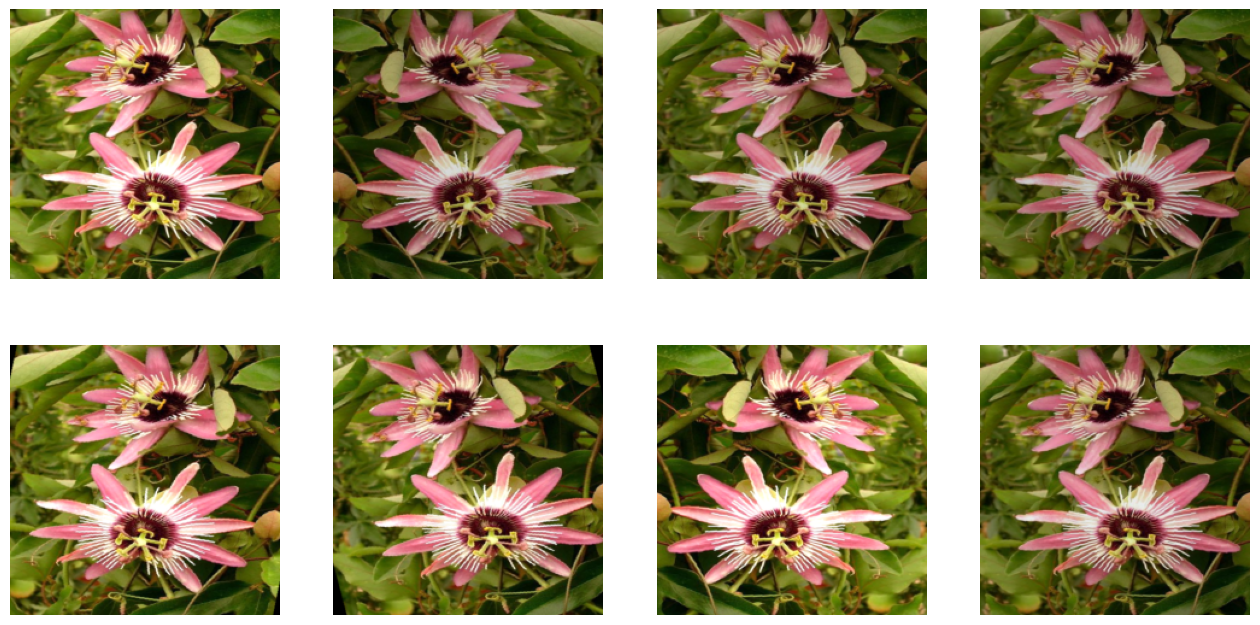

In [34]:
# Display 8 augmented versions of the selected image to see the transformations.
visualize_augmentations(dataset_augmented, idx=sel_idx, num_versions=8)

### Splitting with Augmentation

Now that you have verified the augmentation pipeline, you can apply it specifically to the training subset. Since you already split the raw dataset and wrapped each subset with `SubsetWithTransform` earlier, you only need to re-wrap the training subset with the augmentation transform. The validation and test subsets remain unchanged with the standard preprocessing transform.

In [35]:
# Now apply the specific augmentation pipeline to the training subset
# Val and test subsets remain with the base preprocessing transform applied earlier
train_dataset = SubsetWithTransform(train_subset, transform=augmentation_transform)

You can check that the training dataset has the augmentation transformations applied, while the validation and test datasets do not.

In [36]:
print(train_dataset.transform)
print(val_dataset.transform)
print(test_dataset.transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Robust Datasets

In real-world projects, data pipelines must be resilient to unexpected issues such as corrupted files, inconsistent image formats, or problematic samples that can crash training runs. 
This section introduces robust dataset design strategies.

### Error Handling

You will create a new custom dataset class `RobustFlowerDataset` that extends the original `FlowerDataset` class to handle potential issues with corrupted or problematic images.

The `__init__`, `__len__` and `load_and_correct_labels` methods remain mostly the same as in the original `FlowerDataset` class.

The main differences are:

> `__getitem__`: Implements a try-except block to catch exceptions that may occur when loading an image.
> * If an exception occurs (e.g., due to a corrupted image file), the code will print and log the error by calling the `log_error` method. 
> * It then attempts to retrieve the next image in the dataset instead of stopping execution.

> `retrieve_image`: Handles the actual image loading process. 
> * Constructs the filename and path, verifies image integrity using Pillow's `verify()` method, and reloads the image to ensure it is fully loaded into memory.
> * Checks the image size, raising an error if it is smaller than 32 pixels in either dimension, and converts grayscale images to RGB for consistency.

> `get_error_summary`: Provides a summary of all errors encountered during data loading, useful for debugging and assessing dataset quality.

In [37]:
class RobustFlowerDataset(Dataset):
    """
    A custom dataset class with robust error handling for loading images.

    This class is designed to gracefully handle issues with individual data
    samples, such as corrupted files or incorrect formats. It logs any errors
    and attempts to load a different sample instead of crashing.
    """
    def __init__(self, root_dir, transform=None):
        """
        Initializes the dataset object.

        Args:
            root_dir (str): The root directory where the dataset is stored.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        # Store the root directory path.
        self.root_dir = root_dir
        # Construct the full path to the image directory.
        self.img_dir = os.path.join(root_dir, "jpg")
        # Store the optional transformations.
        self.transform = transform
        # Load and process the labels from the corresponding file.
        self.labels = self.load_and_correct_labels()
        # Initialize a list to keep track of any errors encountered.
        self.error_logs = []

    def __getitem__(self, idx):
        """
        Retrieves a sample, handling errors by trying the next available item.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            image (PIL.Image.Image or torch.Tensor): The processed image data.
            label (int): The corresponding label for the image.
        """
        # Loop to attempt loading a valid sample, preventing an infinite loop.
        for attempt in range(len(self)):
            # Attempt to load and process the sample.
            try:
                # Retrieve the image using the helper method.
                image = self.retrieve_image(idx)
                # Check if a transform has been provided.
                if self.transform:
                    # Apply the transform to the image.
                    image = self.transform(image)
                # Get the label for the current index.
                label = self.labels[idx]
                # Return the valid image and its corresponding label.
                return image, label
            # Catch any exception that occurs during the process.
            except Exception as e:
                # Log the error with its index and message.
                self.log_error(idx, e)
                # Move to the next index, wrapping around if necessary.
                idx = (idx + 1) % len(self)

    def __len__(self):
        """
        Returns the total number of samples in the dataset.

        Returns:
            total_samples (int): The total number of items in the dataset.
        """
        # The total number of samples is the number of labels.
        total_samples = len(self.labels)
        # Return the calculated length.
        return total_samples

    def retrieve_image(self, idx):
        """
        Loads and validates a single image from disk.

        Args:
            idx (int): The index of the image to load.

        Returns:
            image (PIL.Image.Image): The validated and loaded image object.
        """
        # Construct the image filename based on the index.
        img_name = f"image_{idx+1:05d}.jpg"
        # Construct the full path to the image file.
        img_path = os.path.join(self.img_dir, img_name)
        # Open the image file to check its integrity without loading fully.
        with Image.open(img_path) as img:
            # Perform a quick verification of the file's structure.
            img.verify()
        # Re-open the image file after successful verification.
        image = Image.open(img_path)
        # Fully load the image data into memory.
        image.load()
        # Check if the image dimensions are below a minimum threshold.
        if image.size[0] < 32 or image.size[1] < 32:
            # Raise an error for images that are too small.
            raise ValueError(f"Image too small: {image.size}")
        # Check if the image is not in the RGB color mode.
        if image.mode != "RGB":
            # Convert the image to RGB.
            image = image.convert("RGB")
        # Return the fully loaded and validated image.
        return image

    def load_and_correct_labels(self):
        """
        Loads labels from a file and adjusts them.

        Returns:
            labels (numpy.ndarray): An array of zero-indexed integer labels.
        """
        # Load the file containing the labels.
        self.labels_mat = scipy.io.loadmat(
            os.path.join(self.root_dir, "imagelabels.mat")
        )
        # Extract the labels array and correct for zero-based indexing.
        labels = self.labels_mat["labels"][0] - 1
        # Truncate the dataset to the first 10 labels for quick testing.
        labels = labels[:10]
        # Return the processed labels.
        return labels

    def log_error(self, idx, e):
        """
        Records the details of an error encountered during data loading.

        Args:
            idx (int): The index of the problematic sample.
            e (Exception): The exception object that was raised.
        """
        # Construct the filename of the problematic image.
        img_name = f"image_{idx + 1:05d}.jpg"
        # Construct the full path to the image file.
        img_path = os.path.join(self.img_dir, img_name)
        # Append a dictionary with error details to the log.
        self.error_logs.append(
            {
                "index": idx,
                "error": str(e),
                "path": img_path if "img_path" in locals() else "unknown",
            }
        )
        # Print a warning to the console about the skipped image.
        print(f"Warning: Skipping corrupted image {idx}: {e}")

    def get_error_summary(self):
        """
        Prints a summary of all errors encountered during dataset processing.
        """
        # Check if the error log is empty.
        if not self.error_logs:
            # Print a message indicating the dataset is clean.
            print("No errors encountered - dataset is clean!")
        else:
            # Print the total number of problematic images found.
            print(f"\nEncountered {len(self.error_logs)} problematic images:")
            # Iterate through the first few logged errors.
            for error in self.error_logs[:5]:
                # Print the details of an individual error.
                print(f"  Index {error['index']}: {error['error']}")
            # Check if there are more errors than were displayed.
            if len(self.error_logs) > 5:
                # Print a summary of the remaining errors.
                print(f"  ... and {len(self.error_logs) - 5} more")

The Oxford Flowers 102 dataset is clean, but to illustrate robustness techniques, a subset of images in the dataset have been intentionally corrupted. The files of this subset are in the folder `./corrupted_flower_data`.

You can create an instance of the `RobustFlowerDataset` class, passing the path to the corrupted dataset. 

In [38]:
# Define the path to the directory containing the corrupted dataset.
corrupted_dataset_path = './corrupted_flower_data'

# Initialize the robust dataset handler with the path to the corrupted data.
robust_dataset = RobustFlowerDataset(corrupted_dataset_path)

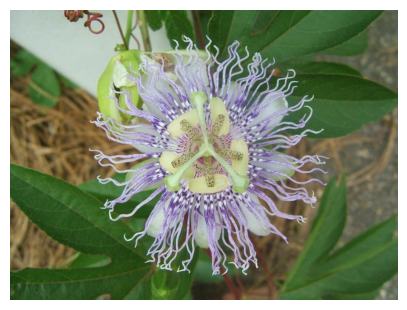

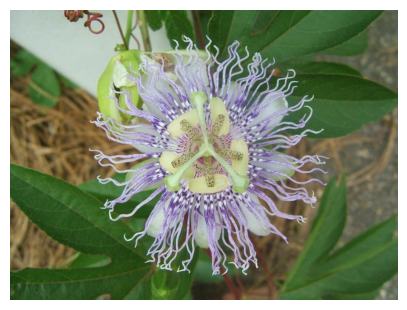

In [39]:
# Set the index to a known corrupted image. Image 2 is tiny
idx = 2

# Attempt to retrieve the image; the robust dataset will skip the bad one and return the next.
img, label = robust_dataset[idx]

# Plot the retrieved image, which should be the one following the corrupted one.
helper_utils_5.plot_img(img)

# Explicitly retrieve the next image in the sequence to verify.
next_img, next_label = robust_dataset[idx + 1]

# Plot the next image; it should be identical to the one above.
helper_utils_5.plot_img(next_img)

In [40]:
# Set the index to a known grayscale image.
# Image 4 is corrupted (grayscale)
idx = 4

# Reconstruct the path to the original image file.
original_img_path = os.path.join(robust_dataset.img_dir, f"image_{idx + 1:05d}.jpg")
# Open the original image directly to check its mode before correction.
original_img = Image.open(original_img_path)
# Print the mode of the original, uncorrected image.
# Prints 'L' for 8-bit grayscale. A standard color image would be 'RGB'.
print(f"Mode of the original image file: {original_img.mode}")  

Mode of the original image file: L


Mode of the corrected image: RGB


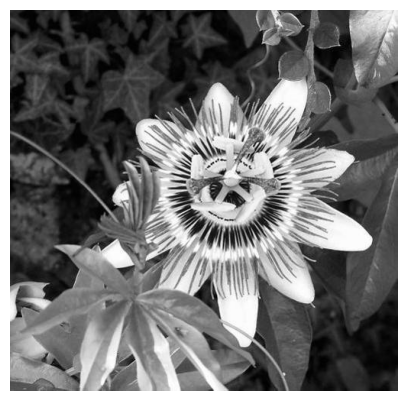

In [41]:
# Retrieve the image; the robust loader should automatically convert it to RGB.
img, label = robust_dataset[idx]

# Plot the image to visually confirm it's now in color.
helper_utils_5.plot_img(img)

# Print the image's mode to confirm it has been corrected to 'RGB'.
print(f"Mode of the corrected image: {img.mode}")

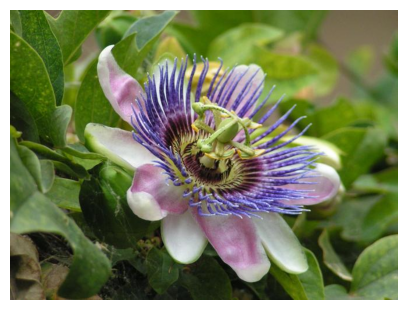

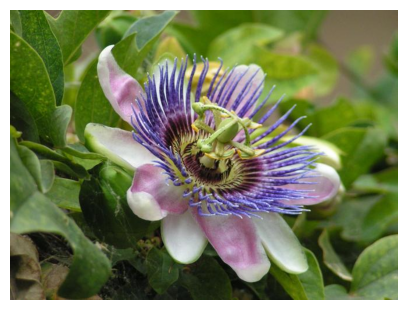

In [42]:
# Set the index to a known corrupted or unreadable image.
idx = 6

# Attempt to retrieve the image; the robust loader should skip the corrupted file and return the next one.
robust_img = robust_dataset[idx][0]

# Plot the retrieved image, which should be the sample from the next index (7).
helper_utils_5.plot_img(robust_img)

# Explicitly retrieve the next image in the sequence to verify the fallback logic.
# Check next image to ensure it's correct
next_img, next_label = robust_dataset[idx + 1]

# Plot the next image; it should be identical to the one above, confirming the skip.
helper_utils_5.plot_img(next_img)

You can see that images 2, 4 and 6 are corrupted in different ways, but the robust dataset class is able to handle those cases accordingly.
You can get a summary of the errors encountered during data loading by inspecting the `error_logs` attribute.

In [43]:
# Display the summary of any corrupted or problematic images found during loading.
robust_dataset.get_error_summary()


Encountered 2 problematic images:
  Index 2: Image too small: (20, 20)
  Index 6: cannot identify image file './corrupted_flower_data/jpg/image_00007.jpg'


### Tracking Errors

In real-world deep learning projects, data pipelines need to be robust not only to corrupted files but also to subtle issues that can silently degrade model performance.
Beyond handling exceptions, it is important to systematically track and analyze the errors and anomalies that occur during data loading and preprocessing.

This final section introduces practical strategies for error tracking within your dataset pipeline.
You will learn how to log problematic samples, monitor which images are accessed (and how often), and review error summaries after training.
These techniques help ensure that your pipeline is resilient, transparent, and production-ready, allowing you to detect and resolve data quality issues before they affect your model's results.

The `MonitoredDataset` class extends `RobustFlowerDataset` to add monitoring features for dataset access and loading performance.

- **Access Tracking**: Each time an image is loaded through `__getitem__`, the class increments a counter for that image index in `self.access_counts`. This allows you to track how often each sample is accessed during training or evaluation.

- **Load Time Measurement**: This class records the time taken to load each image and stores these values in `self.load_times`. If loading an image takes longer than 1 second, a warning is printed with the image index and load time. This helps identify slow-loading samples that may affect training performance.

- **Statistics Reporting**: The `print_stats()` method provides a summary of dataset usage, including:
    - Total number of images in the dataset
    - Number of unique images accessed
    - Number of errors encountered (inherited from the parent class)
    - Average and maximum image load times
    - A warning if any images were never accessed, with examples

These monitoring capabilities help you spot bottlenecks, diagnose errors, and ensure the reliability of your data pipeline, making it easier to debug and optimize dataset handling in deep learning workflows.

In [44]:
class MonitoredDataset(RobustFlowerDataset):
    """
    Extends a robust dataset class to add performance monitoring.

    This class tracks metrics such as how frequently each image is accessed,
    how long each access takes, and which images are never loaded. It provides
    a summary of these statistics to help diagnose data pipeline issues.
    """
    def __init__(self, *args, **kwargs):
        """
        Initializes the monitored dataset object.

        Args:
            *args (tuple): Variable length argument list passed to the parent class.
            **kwargs (dict): Arbitrary keyword arguments passed to the parent class.
        """
        # Initialize the parent class with all provided arguments.
        super().__init__(*args, **kwargs)
        # Initialize a dictionary to count how many times each index is accessed.
        self.access_counts = {}
        # Initialize a list to store the load time for each access.
        self.load_times = []

    def __getitem__(self, idx):
        """
        Retrieves a sample while monitoring access counts and load times.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            result (tuple): The data sample (e.g., image and label) from the parent class.
        """
        # Import the time module for timing operations.
        import time
        # Record the start time of the operation.
        start_time = time.time()
        # Increment the access count for the given index.
        self.access_counts[idx] = self.access_counts.get(idx, 0) + 1
        # Call the parent class's method to load the data.
        result = super().__getitem__(idx)
        # Calculate the total time taken to load the sample.
        load_time = time.time() - start_time
        # Append the calculated load time to the list.
        self.load_times.append(load_time)
        # Check if the load time exceeds a certain threshold.
        if load_time > 1.0:
            # Print a warning if a slow load time is detected.
            print(f"⚠️ Slow load: Image {idx} took {load_time:.2f}s")
        # Return the loaded sample from the parent class.
        return result

    def print_stats(self):
        """
        Prints a summary of the dataset's access statistics and performance.
        """
        # Print a header for the statistics report.
        print("\n=== Pipeline Statistics ===")
        # Display the total number of images in the dataset.
        print(f"Total images: {len(self)}")
        # Display the number of unique images that were accessed.
        print(f"Unique images accessed: {len(self.access_counts)}")
        # Display the total number of errors logged by the parent class.
        print(f"Errors encountered: {len(self.error_logs)}")
        # Check if any load times have been recorded.
        if self.load_times:
            # Calculate the average load time.
            avg_time = sum(self.load_times) / len(self.load_times)
            # Find the maximum (slowest) load time.
            max_time = max(self.load_times)
            # Print the average load time in milliseconds.
            print(f"Average load time: {avg_time*1000:.1f} ms")
            # Print the slowest load time in milliseconds.
            print(f"Slowest load: {max_time*1000:.1f} ms")
        # Create a set of all possible indices in the dataset.
        all_indices = set(range(len(self)))
        # Create a set of all indices that were actually accessed.
        accessed_indices = set(self.access_counts.keys())
        # Find the set of indices that were never accessed.
        never_accessed = all_indices - accessed_indices
        # Check if there are any images that were never loaded.
        if never_accessed:
            # Print a warning message with the count of never-accessed images.
            print(f"\n⚠️ WARNING: {len(never_accessed)} images were never loaded!")
            # Show a few examples of the indices that were never accessed.
            print(f"   Examples: {list(never_accessed)[:5]}")

In [45]:
# Initialize the monitored dataset with the path to the potentially corrupted data.
monitored_dataset = MonitoredDataset(corrupted_dataset_path)

# Loop through every index in the dataset to simulate a full pass.
# Iterate through the dataset to trigger monitoring
for idx in range(len(monitored_dataset)):
    # Access the sample at the current index to trigger the monitoring and error-handling logic.
    img, label = monitored_dataset[idx]

In [46]:
# Print the statistics
monitored_dataset.print_stats()


=== Pipeline Statistics ===
Total images: 10
Unique images accessed: 10
Errors encountered: 2
Average load time: 1.2 ms
Slowest load: 1.6 ms


The `print_stats` method provides a comprehensive overview of the dataset's usage and any issues encountered during data loading.
This is a good practice to implement in your dataset classes, as it helps you monitor the quality of your data and the performance of your data pipeline.

## Conclusion

Congratulations! You have now built a complete, production-ready data pipeline in PyTorch.
In this lab, you moved beyond working with perfectly curated data and learned how to manage the real-world complexities of data handling, from initial access to efficient batching.

You saw how to organize a messy dataset by creating a custom **`Dataset`** class to load images and labels from separate files. You applied essential preprocessing steps, including **transformations** to normalize your data and **data augmentation** to make your future model more robust.

You then used  **`DataLoader`** to prepare your data by batching and shuffling it for training. Finally, you made your pipeline more reliable by implementing error handling and performance monitoring, ensuring that your model's training process is both stable and efficient.

You have built a strong foundation in data management that will support everything you do next.